## step 1. Problem Definition

Predict whether a loan application will be approved or not based on applicant features.

Type: Binary Classification
Target variable: Loan_Status (Approved / Not Approved)

## step 2 import required library




In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## STEP 3 upload and Load Data set

In [68]:
from google.colab import files
uploaded = files.upload() # upload dataset


Saving loan_approval_dataset.csv to loan_approval_dataset (3).csv


In [69]:
df = pd.read_csv('loan_approval_dataset.csv')  #load the datas set
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## STEP 4  Data Understanding (EDA - Exploratory Data Analysis)

In [70]:
print(df.info()) # cheek data type of the feature
print(df.shape) # cheek the size of the data set


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None
(4269, 13)

In [71]:
df.isnull().sum()# cheek missing vlaue


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [72]:
df.describe() # basic statistics


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
# Remove spaces from column names (only once)
df.columns = df.columns.str.strip()

# Clean all object columns
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Check unique values
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [75]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## Visualizations

## 1 heat map

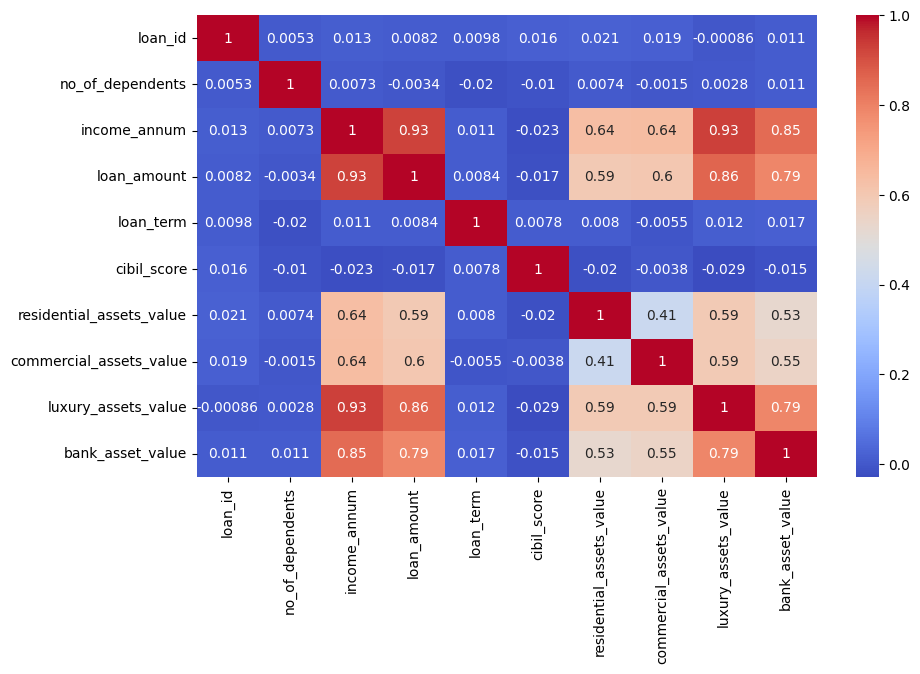

In [76]:


plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

## 2 bar plot for the target variable

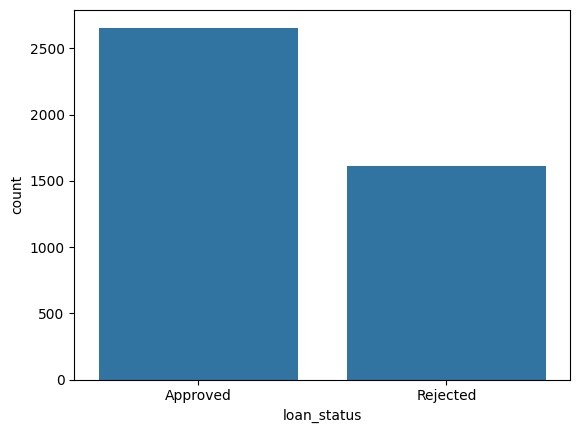

In [77]:
sns.countplot(x='loan_status', data=df)
plt.show()

## 3 Shows how credit score affects approval

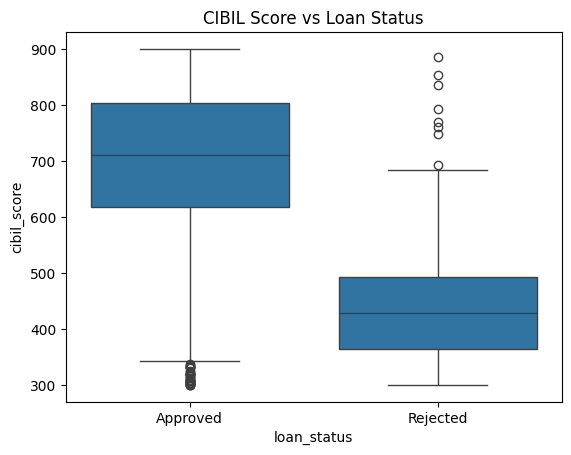

In [78]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title("CIBIL Score vs Loan Status")
plt.show()

### Applicants with higher CIBIL scores are more likely to get loan approval.

## 4. Income Distribution by Loan Status

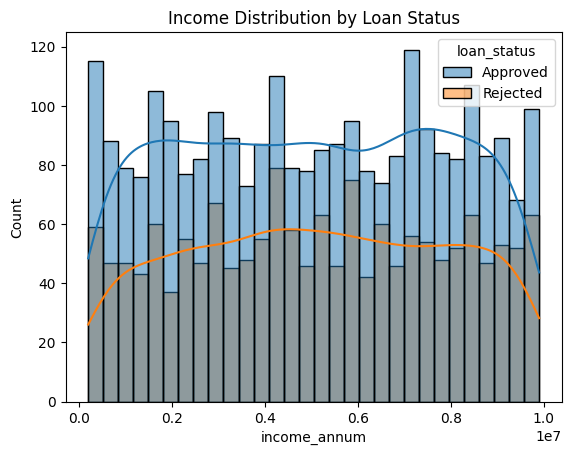

In [79]:
sns.histplot(data=df, x='income_annum', hue='loan_status', bins=30, kde=True)
plt.title("Income Distribution by Loan Status")
plt.show()

## Insight:

Higher income applicants tend to have a higher chance of approval.

## 5. Loan Amount vs Income (Relationship)

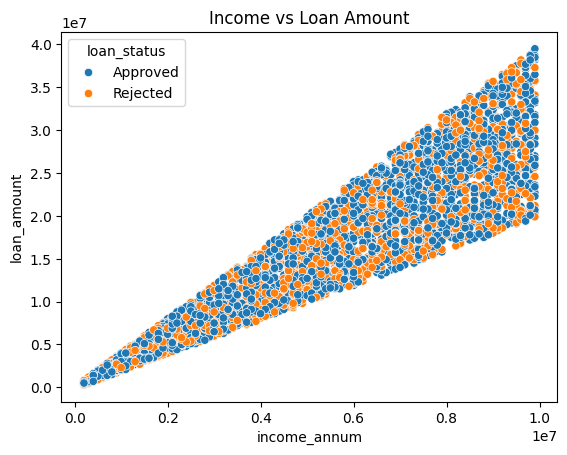

In [80]:
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

## Insight:
Approved loans often align with applicant income capacity.

## 6. Education Impact on Loan Approval

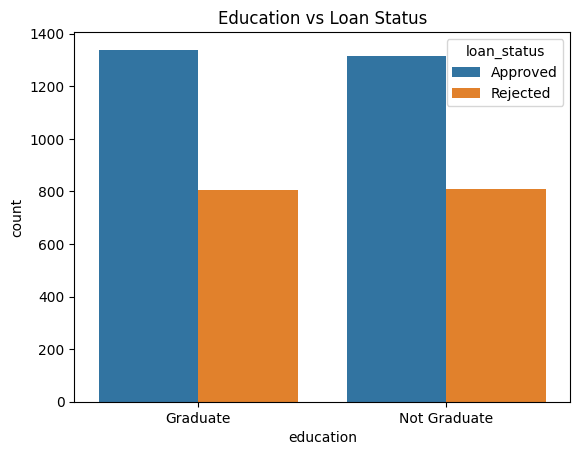

In [81]:
sns.countplot(x='education', hue='loan_status', data=df)
plt.title("Education vs Loan Status")
plt.show()

## Insight:

Graduates may have slightly higher approval rates.

## 7 Total Assets vs Loan Approval


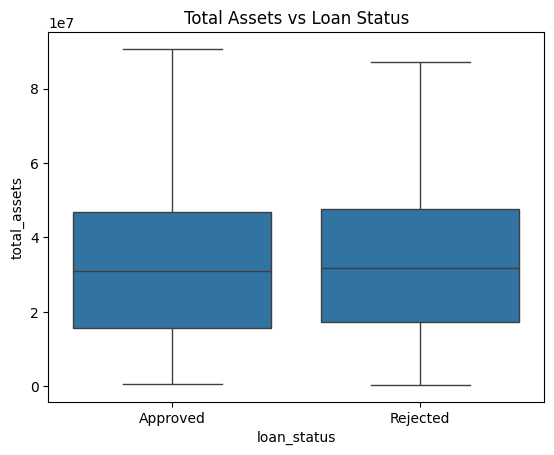

In [82]:
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)
# Create a new feature (this is advanced EDA)
sns.boxplot(x='loan_status', y='total_assets', data=df)
plt.title("Total Assets vs Loan Status")
plt.show()

## Insight:

Higher asset ownership increases chances of loan approval.

## STEP 5: Data Preprocessing

In [83]:
#Drop Unnecessary Columns
df = df.drop('loan_id', axis=1)


In [84]:
#Encode Categorical Variables
df['education'] = df['education'].map({'Graduate':1, 'Not Graduate':0})
df['self_employed'] = df['self_employed'].map({'Yes':1, 'No':0})
df['loan_status'] = df['loan_status'].map({'Approved':1, 'Rejected':0})


In [85]:
# Feature Engineering
df = df.drop([
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
], axis=1)


In [86]:
#Define Features (X) and Target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [87]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## step 6 model building

In [89]:
# Train Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [90]:
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [91]:
# train xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:34:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## STEP 7: Prediction

In [92]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

## STEP 8: Evaluation

In [93]:
# Accuracy Comparison
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.905152224824356
Random Forest: 0.9765807962529274
XGBoost: 0.9882903981264637


In [94]:
# Classification Report for best model
print("Random Forest Report:\n", classification_report(y_test, y_pred_xgb))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       318
           1       0.99      0.99      0.99       536

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



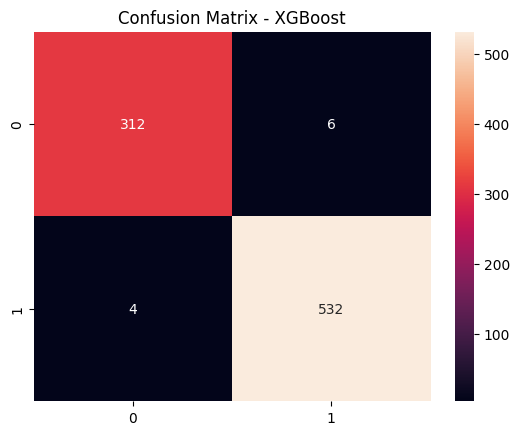

In [95]:
# Confusion Matrix (for best model)

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()


## STEP 9: Model Comparison


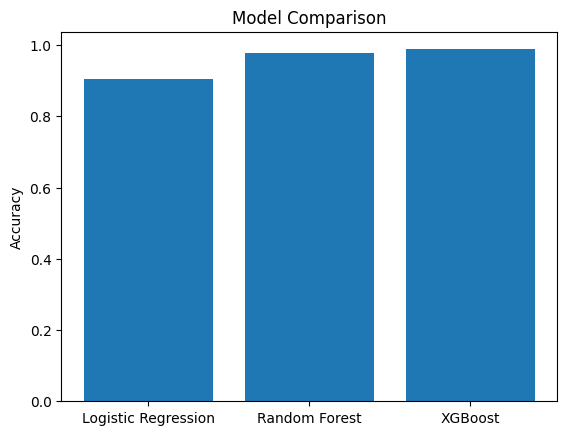

In [96]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

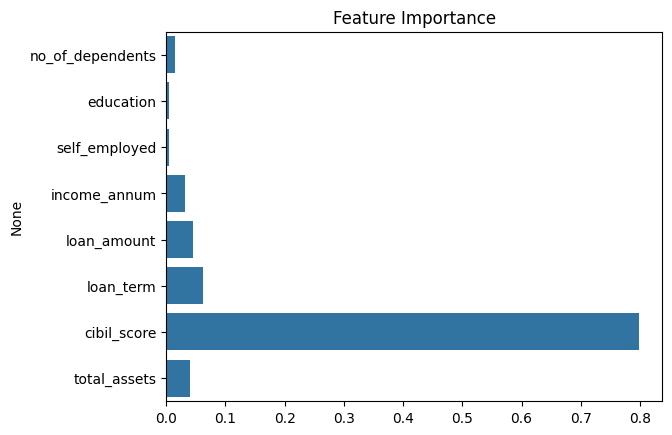

In [97]:
# Feature Importance
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

cibil_score is the  most imprtant factor for  loan approval

## Step 11: Save Model

In [98]:
import joblib
joblib.dump(xgb, 'loan_model.pkl')

['loan_model.pkl']